In [1]:
# 矿物识别模型准确度提升方案（带知识蒸馏）
# 本脚本包含提高模型准确度的步骤，结合了知识蒸馏技术，可导入到Jupyter中分步执行

import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# 步骤1: 数据增强
print("=== 步骤1: 数据增强 ===")
print("数据增强是提高模型泛化能力的有效方法，通过对训练数据进行各种变换，增加数据的多样性。")

# 数据目录
DATA_DIR = 'minet'

# 数据增强变换
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=30),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

transform_val = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 加载数据集
dataset = datasets.ImageFolder(root=DATA_DIR, transform=transform_train)

# 分割训练集和验证集
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
val_dataset.dataset.transform = transform_val

# 创建数据加载器
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

print(f"数据集大小: {len(dataset)}")
print(f"训练集大小: {len(train_dataset)}")
print(f"验证集大小: {len(val_dataset)}")

print("\n=== 步骤1: 数据增强完成 ===")

=== 步骤1: 数据增强 ===
数据增强是提高模型泛化能力的有效方法，通过对训练数据进行各种变换，增加数据的多样性。
数据集大小: 956
训练集大小: 764
验证集大小: 192

=== 步骤1: 数据增强完成 ===


In [2]:
# 步骤2: 模型定义
print("\n=== 步骤2: 模型定义 ===")
print("定义教师模型和学生模型，使用ResNet50作为基础模型。")

# 类别数量
num_classes = len(dataset.classes)

# 设备配置
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用设备: {device}")
print(f"类别数量: {num_classes}")

# 定义教师模型（更复杂的模型）
teacher_model = models.resnet101(pretrained=True)
teacher_model.fc = nn.Linear(teacher_model.fc.in_features, num_classes)
teacher_model.to(device)

# 定义学生模型（目标模型）
student_model = models.resnet50(pretrained=True)
student_model.fc = nn.Linear(student_model.fc.in_features, num_classes)
student_model.to(device)

print("教师模型: ResNet101")
print("学生模型: ResNet50")

print("\n=== 步骤2: 模型定义完成 ===")



=== 步骤2: 模型定义 ===
定义教师模型和学生模型，使用ResNet50作为基础模型。
使用设备: cuda
类别数量: 7


C:\Users\1\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\1\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet101_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet101-63fe2227.pth" to C:\Users\1/.cache\torch\hub\checkpoints\resnet101-63fe2227.pth
100%|███████████████████████████████████████████████████████████████████████████████| 171M/171M [00:10<00:00, 16.7MB/s]
C:\Users\1\AppData\Local\Programs\Python\Python310\lib\si

教师模型: ResNet101
学生模型: ResNet50

=== 步骤2: 模型定义完成 ===


In [4]:
# 步骤3: 知识蒸馏设置
print("\n=== 步骤3: 知识蒸馏设置 ===")
print("设置知识蒸馏的损失函数和参数。")

# 导入知识蒸馏损失函数
class DistillKL(nn.Module):
    def __init__(self, T=3.0):
        super(DistillKL, self).__init__()
        self.T = T

    def forward(self, y_s, y_t):
        p_s = torch.nn.functional.log_softmax(y_s / self.T, dim=1)
        p_t = torch.nn.functional.softmax(y_t / self.T, dim=1)
        loss = torch.nn.functional.kl_div(p_s, p_t, reduction='sum') * (self.T ** 2) / y_s.shape[0]
        return loss

# 定义损失函数
criterion_ce = nn.CrossEntropyLoss()  # 分类损失

# 定义优化器
optimizer = optim.Adam(student_model.parameters(), lr=0.001, weight_decay=1e-4)

# 学习率调度器
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

# 蒸馏参数（固定值）
alpha = 0.3  # 蒸馏损失权重
temperature = 2.0  # 温度参数

# 创建蒸馏损失函数
criterion_kd = DistillKL(T=temperature)

print("优化器: Adam")
print("初始学习率: 0.001")
print("学习率调度: StepLR (每5个epoch衰减10倍)")
print(f"蒸馏参数 - alpha: {alpha}, temperature: {temperature}")

print("\n=== 步骤3: 知识蒸馏设置完成 ===")



=== 步骤3: 知识蒸馏设置 ===
设置知识蒸馏的损失函数和参数。
优化器: Adam
初始学习率: 0.001
学习率调度: StepLR (每5个epoch衰减10倍)
蒸馏参数 - alpha: 0.3, temperature: 2.0

=== 步骤3: 知识蒸馏设置完成 ===


In [5]:
# 步骤4: 训练教师模型
print("\n=== 步骤4: 训练教师模型 ===")
print("首先训练教师模型，作为知识蒸馏的知识来源。")

# 教师模型训练参数
teacher_epochs = 10

# 教师模型优化器
teacher_optimizer = optim.Adam(teacher_model.parameters(), lr=0.001, weight_decay=1e-4)
teacher_scheduler = optim.lr_scheduler.StepLR(teacher_optimizer, step_size=5, gamma=0.1)

print(f"开始训练教师模型, 共 {teacher_epochs} 个epoch...")

for epoch in range(teacher_epochs):
    print(f"\nEpoch {epoch+1}/{teacher_epochs}")
    
    # 训练阶段
    teacher_model.train()
    running_loss = 0.0
    train_correct = 0
    train_total = 0
    
    for batch_idx, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)
        
        teacher_optimizer.zero_grad()
        outputs = teacher_model(inputs)
        loss = criterion_ce(outputs, labels)
        loss.backward()
        teacher_optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()
        
        if batch_idx % 10 == 0:
            print(f"  Batch {batch_idx}/{len(train_loader)}, Loss: {loss.item():.4f}")
    
    train_loss = running_loss / len(train_dataset)
    train_accuracy = 100 * train_correct / train_total
    
    # 验证阶段
    teacher_model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = teacher_model(inputs)
            loss = criterion_ce(outputs, labels)
            val_loss += loss.item() * inputs.size(0)
            
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    val_loss = val_loss / len(val_dataset)
    val_accuracy = 100 * correct / total
    
    teacher_scheduler.step()
    
    print(f"  训练损失: {train_loss:.4f}, 训练准确率: {train_accuracy:.2f}%")
    print(f"  验证损失: {val_loss:.4f}, 验证准确率: {val_accuracy:.2f}%")

print("\n教师模型训练完成!")
print(f"教师模型最终验证准确率: {val_accuracy:.2f}%")

# 保存教师模型
teacher_model_path = 'teacher_resnet101.pth'
torch.save({
    'model_state_dict': teacher_model.state_dict(),
    'val_accuracy': val_accuracy,
    'classes': dataset.classes
}, teacher_model_path)
print(f"教师模型保存到: {teacher_model_path}")

print("\n=== 步骤4: 训练教师模型完成 ===")




=== 步骤4: 训练教师模型 ===
首先训练教师模型，作为知识蒸馏的知识来源。
开始训练教师模型, 共 10 个epoch...

Epoch 1/10
  Batch 0/24, Loss: 2.0023
  Batch 10/24, Loss: 1.5983
  Batch 20/24, Loss: 2.4958
  训练损失: 1.3274, 训练准确率: 55.89%
  验证损失: 14.6045, 验证准确率: 34.90%

Epoch 2/10
  Batch 0/24, Loss: 1.2111
  Batch 10/24, Loss: 0.6331
  Batch 20/24, Loss: 1.1246
  训练损失: 0.9103, 训练准确率: 71.47%
  验证损失: 0.9016, 验证准确率: 69.79%

Epoch 3/10
  Batch 0/24, Loss: 1.0513
  Batch 10/24, Loss: 0.5444
  Batch 20/24, Loss: 0.2895
  训练损失: 0.6261, 训练准确率: 79.19%
  验证损失: 0.9706, 验证准确率: 67.71%

Epoch 4/10
  Batch 0/24, Loss: 0.7905
  Batch 10/24, Loss: 0.4765
  Batch 20/24, Loss: 0.3158
  训练损失: 0.6609, 训练准确率: 79.32%
  验证损失: 1.1180, 验证准确率: 66.67%

Epoch 5/10
  Batch 0/24, Loss: 0.5865
  Batch 10/24, Loss: 0.4199
  Batch 20/24, Loss: 0.9928
  训练损失: 0.6395, 训练准确率: 78.01%
  验证损失: 0.8890, 验证准确率: 73.44%

Epoch 6/10
  Batch 0/24, Loss: 0.4997
  Batch 10/24, Loss: 0.4578
  Batch 20/24, Loss: 0.5276
  训练损失: 0.4727, 训练准确率: 84.42%
  验证损失: 0.5807, 验证准确率: 80.21%



In [6]:
# 步骤5: 知识蒸馏训练学生模型
print("\n=== 步骤5: 知识蒸馏训练学生模型 ===")
print("使用教师模型的知识来训练学生模型。")

# 学生模型训练参数
student_epochs = 20

# 记录训练过程
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

print(f"开始知识蒸馏训练, 共 {student_epochs} 个epoch...")

for epoch in range(student_epochs):
    print(f"\nEpoch {epoch+1}/{student_epochs}")
    
    # 训练阶段
    student_model.train()
    teacher_model.eval()  # 教师模型在蒸馏过程中保持评估模式
    running_loss = 0.0
    train_correct = 0
    train_total = 0
    
    for batch_idx, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        
        # 学生模型前向传播
        student_outputs = student_model(inputs)
        
        # 教师模型前向传播（无梯度）
        with torch.no_grad():
            teacher_outputs = teacher_model(inputs)
        
        # 计算损失
        loss_ce = criterion_ce(student_outputs, labels)  # 分类损失
        loss_kd = criterion_kd(student_outputs, teacher_outputs)  # 蒸馏损失
        loss = (1 - alpha) * loss_ce + alpha * loss_kd  # 总损失
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(student_outputs, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()
        
        if batch_idx % 10 == 0:
            print(f"  Batch {batch_idx}/{len(train_loader)}, Loss: {loss.item():.4f}, CE Loss: {loss_ce.item():.4f}, KD Loss: {loss_kd.item():.4f}")
    
    train_loss = running_loss / len(train_dataset)
    train_accuracy = 100 * train_correct / train_total
    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)
    
    # 验证阶段
    student_model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = student_model(inputs)
            loss = criterion_ce(outputs, labels)
            val_loss += loss.item() * inputs.size(0)
            
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    val_loss = val_loss / len(val_dataset)
    val_accuracy = 100 * correct / total
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)
    
    scheduler.step()
    
    print(f"  训练损失: {train_loss:.4f}, 训练准确率: {train_accuracy:.2f}%")
    print(f"  验证损失: {val_loss:.4f}, 验证准确率: {val_accuracy:.2f}%")

print("\n知识蒸馏训练完成!")
print(f"学生模型最终验证准确率: {val_accuracy:.2f}%")

print("\n=== 步骤5: 知识蒸馏训练学生模型完成 ===")


=== 步骤5: 知识蒸馏训练学生模型 ===
使用教师模型的知识来训练学生模型。
开始知识蒸馏训练, 共 20 个epoch...

Epoch 1/20
  Batch 0/24, Loss: 2.8331, CE Loss: 1.9486, KD Loss: 4.8971
  Batch 10/24, Loss: 1.1357, CE Loss: 0.8569, KD Loss: 1.7862
  Batch 20/24, Loss: 1.6550, CE Loss: 1.3233, KD Loss: 2.4291
  训练损失: 1.5078, 训练准确率: 63.22%
  验证损失: 2.6209, 验证准确率: 56.77%

Epoch 2/20
  Batch 0/24, Loss: 1.2593, CE Loss: 0.9992, KD Loss: 1.8663
  Batch 10/24, Loss: 0.8580, CE Loss: 0.7027, KD Loss: 1.2203
  Batch 20/24, Loss: 1.0931, CE Loss: 0.9311, KD Loss: 1.4712
  训练损失: 0.9388, 训练准确率: 72.64%
  验证损失: 1.0271, 验证准确率: 70.83%

Epoch 3/20
  Batch 0/24, Loss: 0.5250, CE Loss: 0.4263, KD Loss: 0.7553
  Batch 10/24, Loss: 0.6981, CE Loss: 0.5299, KD Loss: 1.0906
  Batch 20/24, Loss: 0.7281, CE Loss: 0.6513, KD Loss: 0.9073
  训练损失: 0.8154, 训练准确率: 76.96%
  验证损失: 0.8888, 验证准确率: 79.69%

Epoch 4/20
  Batch 0/24, Loss: 0.4888, CE Loss: 0.3762, KD Loss: 0.7516
  Batch 10/24, Loss: 0.6137, CE Loss: 0.4789, KD Loss: 0.9281
  Batch 20/24, Loss: 0.554


=== 步骤6: 可视化训练过程 ===
绘制训练和验证的损失及准确率曲线。


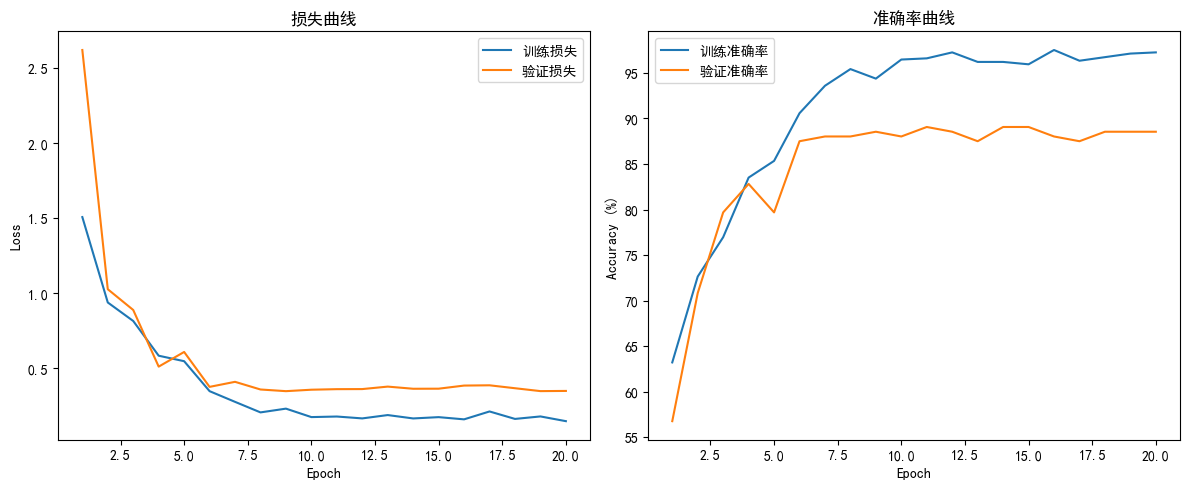


=== 步骤6: 可视化训练过程完成 ===


In [8]:
# 步骤6: 可视化训练过程
print("\n=== 步骤6: 可视化训练过程 ===")
print("绘制训练和验证的损失及准确率曲线。")
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans', 'Arial Unicode MS', 'WenQuanYi Zen Hei']
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题
# 绘制损失曲线
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, student_epochs+1), train_losses, label='训练损失')
plt.plot(range(1, student_epochs+1), val_losses, label='验证损失')
plt.title('损失曲线')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# 绘制准确率曲线
plt.subplot(1, 2, 2)
plt.plot(range(1, student_epochs+1), train_accuracies, label='训练准确率')
plt.plot(range(1, student_epochs+1), val_accuracies, label='验证准确率')
plt.title('准确率曲线')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.tight_layout()
plt.show()

print("\n=== 步骤6: 可视化训练过程完成 ===")

In [9]:
# 步骤7: 保存模型
print("\n=== 步骤7: 保存模型 ===")
print("保存训练好的学生模型。")

# 保存学生模型
model_save_path = 'baseline_resnet50_distilled.pth'
print(f"\n保存模型到: {model_save_path}")

torch.save({
    'model_state_dict': student_model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'val_accuracy': val_accuracy,
    'classes': dataset.classes
}, model_save_path)

print(f"模型保存成功!")
print(f"模型文件大小: {os.path.getsize(model_save_path) / 1024 / 1024:.2f} MB")

print("\n=== 步骤7: 保存模型完成 ===")



=== 步骤7: 保存模型 ===
保存训练好的学生模型。

保存模型到: baseline_resnet50_distilled.pth
模型保存成功!
模型文件大小: 269.64 MB

=== 步骤7: 保存模型完成 ===


In [10]:
# 步骤8: 模型评估
print("\n=== 步骤8: 模型评估 ===")
print("评估模型在验证集上的表现。")

# 评估模型
student_model.eval()
correct = 0
total = 0
class_correct = {cls: 0 for cls in dataset.classes}
class_total = {cls: 0 for cls in dataset.classes}

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = student_model(inputs)
        _, predicted = torch.max(outputs, 1)
        
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        # 统计每个类别的准确率
        for i in range(len(labels)):
            label = labels[i].item()
            class_total[dataset.classes[label]] += 1
            if predicted[i] == label:
                class_correct[dataset.classes[label]] += 1

print(f"验证集准确率: {100 * correct / total:.2f}%")

print("\n每个类别的准确率:")
for cls in dataset.classes:
    if class_total[cls] > 0:
        print(f"{cls}: {100 * class_correct[cls] / class_total[cls]:.2f}% ({class_correct[cls]}/{class_total[cls]})")
    else:
        print(f"{cls}: N/A (0/0)")

print("\n=== 步骤8: 模型评估完成 ===")



=== 步骤8: 模型评估 ===
评估模型在验证集上的表现。
验证集准确率: 88.54%

每个类别的准确率:
biotite: 94.74% (18/19)
bornite: 90.32% (28/31)
chrysocolla: 91.43% (32/35)
malachite: 86.96% (40/46)
muscovite: 75.00% (12/16)
pyrite: 77.27% (17/22)
quartz: 100.00% (23/23)

=== 步骤8: 模型评估完成 ===


In [11]:
# 步骤9: 预测示例
print("\n=== 步骤9: 预测示例 ===")
print("使用训练好的模型进行预测示例。")

# 预测函数
def predict_image(image_path, model, transform):
    """使用模型预测图片"""
    try:
        # 加载图片
        image = Image.open(image_path).convert('RGB')
        
        # 预处理
        img_tensor = transform(image).unsqueeze(0).to(device)
        
        # 预测
        model.eval()
        with torch.no_grad():
            outputs = model(img_tensor)
            _, predicted = torch.max(outputs, 1)
            confidence = torch.nn.functional.softmax(outputs, dim=1)[0][predicted.item()].item()
        
        # 获取类别名称
        predicted_class = dataset.classes[predicted.item()]
        
        return predicted_class, confidence
    except Exception as e:
        return str(e), 0.0

# 预测示例
sample_images = [
    'minet/biotite/0001.jpg',
    'minet/bornite/0001.jpg',
    'minet/chrysocolla/0001.jpg',
    'minet/malachite/0001.jpg',
    'minet/muscovite/0001.jpg',
    'minet/pyrite/0001.jpg',
    'minet/quartz/0001.jpg'
]

print("预测示例:")
for image_path in sample_images:
    if os.path.exists(image_path):
        predicted_class, confidence = predict_image(image_path, student_model, transform_val)
        print(f"图片: {image_path.split('/')[-2]}/{image_path.split('/')[-1]}")
        print(f"预测结果: {predicted_class}")
        print(f"置信度: {confidence:.2f}")
        print()
    else:
        print(f"图片不存在: {image_path}")
        print()

print("\n=== 步骤9: 预测示例完成 ===")


=== 步骤9: 预测示例 ===
使用训练好的模型进行预测示例。
预测示例:
图片: biotite/0001.jpg
预测结果: biotite
置信度: 1.00

图片: bornite/0001.jpg
预测结果: bornite
置信度: 1.00

图片: chrysocolla/0001.jpg
预测结果: chrysocolla
置信度: 0.97

图片: malachite/0001.jpg
预测结果: malachite
置信度: 0.88

图片: muscovite/0001.jpg
预测结果: muscovite
置信度: 0.93

图片: pyrite/0001.jpg
预测结果: pyrite
置信度: 0.98

图片: quartz/0001.jpg
预测结果: quartz
置信度: 0.97


=== 步骤9: 预测示例完成 ===
